Once deleted, variables cannot be recovered. Proceed (y/[n])? y


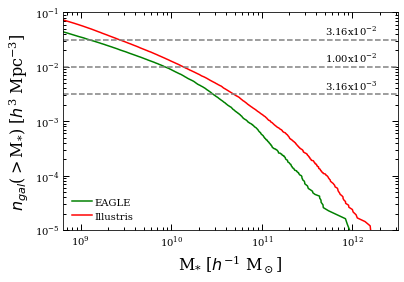

In [5]:
%matplotlib inline
%reset

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import h5py

#EAGLE simulation    
h=0.6777
volumes = (100.0 * h )**3 #Mpc3/h3

data = ascii.read("For_HMF_EAGLE.dat", data_start=1, delimiter=',')
Ms_E = data["masstype_star"] * h #Msun/h
#Con corte de 1e8.5 Msun/h
Ms_E_cut = Ms_E[Ms_E >= 10**8.5]
Ng = len(Ms_E_cut)
Ms_E_cut_ord = np.sort(Ms_E_cut)
Ms_E_cut_ord = Ms_E_cut_ord[::-1]

accum = np.zeros(Ng)
for i in range(1,Ng-1):    
    accum[i] = accum[i-1] + 1
 
plt.plot(Ms_E_cut_ord, accum/volumes, color="green", label="EAGLE")


#Illustris simulation
h = 0.704
volumes = (106.5 * h )**3 #Mpc3/h3
#Version vieja a la que le faltaban algunas galaxias menos masivas
#basePath = '/cosma/home/cartale/AssemblyBias/Illustris/'
#f = h5py.File(basePath+'groups_135.0.hdf5','r')

#sub_mass_aux = f['Subhalo']['SubhaloMassType']
#Ms_I_aux =  sub_mass_aux[:,4]*1e+10 #Masa estelar en Msun/h
#Ms_I = Ms_I_aux[Ms_I_aux >= 10**8.5]
#Ms_I_ord = np.sort(Ms_I)
#Ms_I_ord = Ms_I_ord[::-1]
#Ngi = len(Ms_I_ord)

#accum = np.zeros(Ngi)
#for i in range(1,Ngi-1):    
#    accum[i] = accum[i-1] + 1    
#plt.plot(Ms_I_ord, accum/volumes, color="red", label="Illustris")

#Illustris simulation
data = ascii.read("/cosma/home/cartale/AssemblyBias/Environment/Illustris-table.dat", data_start=1, delimiter='\t')
Ms_E = data["Ms"] #Msun/h
#Con corte de 1e8.5 Msun/h
Ms_E_cut = Ms_E[Ms_E >= 10**8.5]
Ng = len(Ms_E_cut)
Ms_E_cut_ord = np.sort(Ms_E_cut)
Ms_E_cut_ord = Ms_E_cut_ord[::-1]

accum = np.zeros(Ng)
for i in range(1,Ng-1):    
    accum[i] = accum[i-1] + 1
 
plt.plot(Ms_E_cut_ord, accum/volumes, color="red", label="Illustris")


plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"M$_{*}$ [$h^{-1}$ M$_\odot$]")
#plt.ylabel(r"N$_{gal}$/V [$h^{3}$ Mpc$^{-3}$]")
plt.ylabel(r"$n_{gal} (> $M$_{*})$ [$h^{3}$ Mpc$^{-3}$]")

plt.axis([2*10**8.5,10**12.5,0.00001,0.1])
plt.legend(loc=3, frameon=False)
plt.tick_params(which="both",direction='in', bottom="on", top="on", left="on", right="on")

x=[10**7.5, 10**13.5]
y1 = [0.01,0.01]
y2 = [0.001,0.001]
y3 = [3.16e-3,3.16e-3]
y4 = [0.0316, 0.0316]
plt.plot(x,y1, color="grey", ls="--")
#plt.plot(x,y2, color="grey", ls="--")
plt.plot(x,y3, color="grey", ls="--")
plt.plot(x,y4, color="grey", ls="--")

plt.text(5e11,0.0316*1.2,"3.16x$10^{-2}$")
plt.text(5e11,0.01*1.2,"1.00x$10^{-2}$")
plt.text(5e11,0.00316*1.2,"3.16x$10^{-3}$")

figure2 = plt.gcf() #acá te quedarias con la referencia a la figura.
plt.show()
figure2.savefig("CSMF-EAGLE-Illustris-z0.eps", bbox_inches='tight')  #guardas

